In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

Fitted Line: y = 5.8203x + 0.0006
R-squared: 0.9978


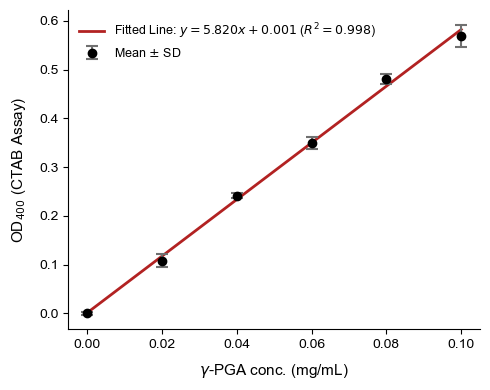

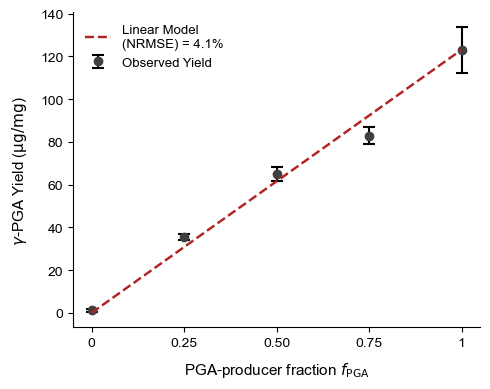

In [9]:
# Expt 9 - PGA Quantification
from scipy.optimize import curve_fit

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['axes.unicode_minus'] = False
SC_add = r"C:\Users\ayantis\Desktop\PhD\Research\Project 1 - Formation of a swelling gel underlies a morphological transition in Bacillus subtilis biofilms\PNAS submission\Revision\Review experiments\Review expt #9\Attempt 5\CTAB assay supernanat-DNase+ProteinaseK.xlsx"
SC = pd.read_excel(SC_add, usecols = ["Mean OD_400", "SD OD_400"], sheet_name = "SC Curve")
SC = SC.iloc[[0, 1, 2, 3, 4, 5]]
OD_400 = SC["Mean OD_400"]
SD = SC["SD OD_400"]

conc = np.array([0, 0.02, 0.04, 0.06, 0.08, 0.1])
def linear_model(x, m, c):
    return m * x + c

x_data = conc
y_data = OD_400 - OD_400[0]

popt, pcov = curve_fit(linear_model, x_data, y_data)
slope, intercept = popt
residuals = y_data - linear_model(x_data,*popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r = 1 - (ss_res / ss_tot)

print(f"Fitted Line: y = {slope:.4f}x + {intercept:.4f}")
print(f"R-squared: {r:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(x_data, y_data, yerr = SD, fmt='o', 
            color='black', ecolor ='#707070', elinewidth=1.5,
            capsize=4, capthick=1.5, linewidth=0, markersize=6, 
            label=r'Mean $\pm$ SD', zorder=3)

ax.plot(x_data, linear_model(x_data, *popt), color='firebrick', linestyle='-', 
        linewidth=2, label=f"Fitted Line: $y = {slope:.3f}x + {intercept:.3f}$ ($R^2 = {r:.3f}$)", zorder=2)
ax.set_xlabel(r"$\gamma$-PGA conc. (mg/mL)", fontsize=11, labelpad=8)
ax.set_ylabel(r"OD$_{400}$ (CTAB Assay)", fontsize=11, labelpad=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.savefig(r"C:\Users\ayantis\Desktop\PhD\Research\Project 1 - Formation of a swelling gel underlies a morphological transition in Bacillus subtilis biofilms\PNAS submission\Revision\Review experiments\Review expt #9\SC curve.svg", format = "svg", dpi = 600)
plt.show()


file = pd.read_excel(
    r"C:\Users\ayantis\Desktop\PhD\Research\Project 1 - Formation of a swelling gel underlies a morphological transition in Bacillus subtilis biofilms\PNAS submission\Revision\Review experiments\Review expt #9\Attempt 5\CTAB assay supernanat-DNase+ProteinaseK.xlsx",
    sheet_name="Sheet1-Supernatant Day 1",
    usecols=["Dry Biomass (mg)", "Mean OD_400", "SD OD_400"]
)

fig, ax = plt.subplots(figsize=(5, 4))

DF1 = 910 / 800
DF2 = 450 / 150
DF3 = 200 / 100
DF = DF1 * DF2 * DF3


m = popt[0]
c = popt[1]
V_s = 1 # biofilms were suspendened in 1mL DI H2O
dry_mass = np.array(file["Dry Biomass (mg)"].iloc[[1,2,3,4,5]])
PGA_concentration = np.array(((file["Mean OD_400"].iloc[[1,2,3,4,5]] - c) / (m * dry_mass)) * DF * V_s * 1000)
PGA_concentration_SD = file["SD OD_400"].iloc[[1,2,3,4,5]] * DF * 1000 / (m * dry_mass)

x_positions = np.array([0, 0.25, 0.50, 0.75, 1])

y_observed = np.array(PGA_concentration)
max_value = y_observed[-1] 
y_theoretical = x_positions * max_value

nrmse = np.sqrt(np.mean((y_observed - y_theoretical) ** 2)) * 100 / (np.max(y_observed) - np.min(y_observed))

ax.errorbar(
    x_positions, 
    PGA_concentration, 
    yerr=PGA_concentration_SD,
    fmt = "o",
    color='#404040',            
    label='Observed Yield',
    ecolor='black', elinewidth=1.5, capsize=4, capthick=1.5,
    zorder=3 )

ax.plot([0, max_value], 
    color='firebrick', 
    linestyle='--', 
    linewidth=1.75,
    label=f'Linear Model\n(NRMSE) = {nrmse:.1f}%', 
    zorder=4
)

ax.set_xlabel(r"PGA-producer fraction $f_{\mathrm{PGA}}$", fontsize=11, labelpad=8)
ax.set_ylabel(r"$\gamma$-PGA Yield ($\mathrm{\mu g/mg}$)", fontsize=11, labelpad=8)

ax.set_xticks(x_positions)
ax.set_xticklabels(['0', '0.25', '0.50', '0.75', '1'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend(frameon=False, fontsize=9.5, loc='upper left')
plt.tight_layout()
plt.savefig(r"C:\Users\ayantis\Desktop\PhD\Research\Project 1 - Formation of a swelling gel underlies a morphological transition in Bacillus subtilis biofilms\PNAS submission\Revision\Review experiments\Review expt #9\PGA yield curve.svg", format = "svg", dpi = 600)
plt.show()

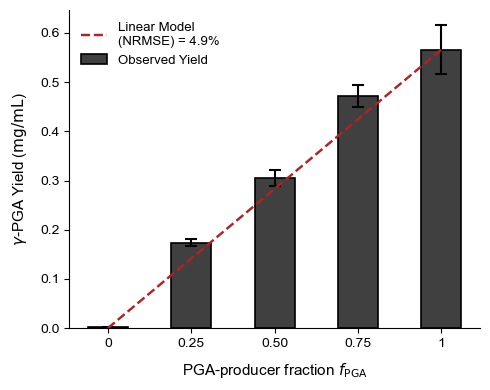

In [10]:
#Attempt 5
file = pd.read_excel(
    r"C:\Users\ayantis\Desktop\PhD\Research\Project 1 - Formation of a swelling gel underlies a morphological transition in Bacillus subtilis biofilms\PNAS submission\Revision\Review experiments\Review expt #9\Attempt 5\CTAB assay supernanat-DNase+ProteinaseK.xlsx",
    sheet_name="Sheet1-Supernatant Day 1",
    usecols=["Dry Biomass (mg)", "Mean OD_400", "SD OD_400"]
)

fig, ax = plt.subplots(figsize=(5, 4))

DF1 = 910 / 800
DF2 = 450 / 150
DF3 = 200 / 100
DF = DF1 * DF2 * DF3

PGA_concentration = np.array(((file["Mean OD_400"].iloc[[1,2,3,4,5]] - popt[1]) / popt[0]) * DF)
PGA_concentration_SD = file["SD OD_400"].iloc[[1,2,3,4,5]] * DF / popt[0]
x_positions = np.array([0, 0.25, 0.50, 0.75, 1])

y_observed = np.array(PGA_concentration)
max_value = y_observed[-1] 
y_theoretical = x_positions * max_value

nrmse = np.sqrt(np.mean((y_observed - y_theoretical) ** 2)) * 100 / (np.max(y_observed) - np.min(y_observed))

ax.bar(
    x_positions, 
    PGA_concentration, 
    yerr=PGA_concentration_SD, 
    width=0.12,                  
    color='#404040',             
    edgecolor='black',           
    linewidth=1.2,
    label='Observed Yield',
    error_kw=dict(ecolor='black', elinewidth=1.5, capsize=4, capthick=1.5),
    zorder=3 )

ax.plot([0, max_value], 
    color='firebrick', 
    linestyle='--', 
    linewidth=1.75,
    label=f'Linear Model\n(NRMSE) = {nrmse:.1f}%', 
    zorder=4
)

ax.set_xlabel(r"PGA-producer fraction $f_{\mathrm{PGA}}$", fontsize=11, labelpad=8)
ax.set_ylabel(r"$\gamma$-PGA Yield ($\mathrm{mg/mL}$)", fontsize=11, labelpad=8)

ax.set_xticks(x_positions)
ax.set_xticklabels(['0', '0.25', '0.50', '0.75', '1'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend(frameon=False, fontsize=9.5, loc='upper left')
plt.tight_layout()
plt.savefig(r"C:\Users\ayantis\Desktop\PhD\Research\Project 1 - Formation of a swelling gel underlies a morphological transition in Bacillus subtilis biofilms\PNAS submission\Revision\Review experiments\Review expt #9\PGA yield curve bar.svg", format = "svg", dpi = 600)
plt.show()

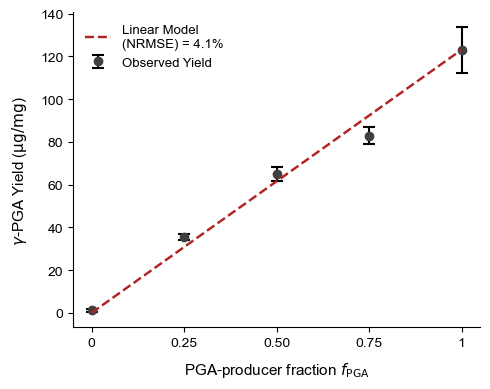

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))

m = popt[0]
c = popt[1]
V_s = 1 # biofilms were suspendened in 1mL DI H2O
dry_mass = np.array(file["Dry Biomass (mg)"].iloc[[1,2,3,4,5]])
PGA_concentration = np.array(((file["Mean OD_400"].iloc[[1,2,3,4,5]] - c) / (m * dry_mass)) * DF * V_s * 1000)
PGA_concentration_SD = file["SD OD_400"].iloc[[1,2,3,4,5]] * DF * 1000 / (m * dry_mass)

x_positions = np.array([0, 0.25, 0.50, 0.75, 1])

y_observed = np.array(PGA_concentration)
max_value = y_observed[-1] 
y_theoretical = x_positions * max_value

nrmse = np.sqrt(np.mean((y_observed - y_theoretical) ** 2)) * 100 / (np.max(y_observed) - np.min(y_observed))

ax.errorbar(
    x_positions, 
    PGA_concentration, 
    yerr=PGA_concentration_SD,
    fmt = "o",
    color='#404040',            
    label='Observed Yield',
    ecolor='black', elinewidth=1.5, capsize=4, capthick=1.5,
    zorder=3 )

ax.plot([0, max_value], 
    color='firebrick', 
    linestyle='--', 
    linewidth=1.75,
    label=f'Linear Model\n(NRMSE) = {nrmse:.1f}%', 
    zorder=4
)

ax.set_xlabel(r"PGA-producer fraction $f_{\mathrm{PGA}}$", fontsize=11, labelpad=8)
ax.set_ylabel(r"$\gamma$-PGA Yield ($\mathrm{\mu g/mg}$)", fontsize=11, labelpad=8)

ax.set_xticks(x_positions)
ax.set_xticklabels(['0', '0.25', '0.50', '0.75', '1'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend(frameon=False, fontsize=9.5, loc='upper left')
plt.tight_layout()
plt.savefig(r"C:\Users\ayantis\Desktop\PhD\Research\Project 1 - Formation of a swelling gel underlies a morphological transition in Bacillus subtilis biofilms\PNAS submission\Revision\Review experiments\Review expt #9\PGA yield curve.svg", format = "svg", dpi = 600)
plt.show()